# Notebook 1 - OLS and Ridge on the Runge function

Project 1, parts a and b.

Anne Kristin Furu, FYS-STK4155, fall 2026.

## Setup

The reusable code lives in the `.py` modules at the repo root. This notebook imports from them and holds only the analysis.

In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from common import BLUE, RED, YELLOW, GREY, GREEN, SEED, savefig
from Get_data import make_data, polynomial_features, scale_center, split
from Errors import mse, r2
from OLS import ols_svd, ols_pinv
from Ridge import ridge_closed_form
np.set_printoptions(precision=4, suppress=True)

## Part a: OLS

We fit Runge's function $f(x) = 1/(1+25x^2)$ on $[-1,1]$ with ordinary least squares, using our own SVD solver, for polynomial degrees up to 15. The data has $n=100$ points and Gaussian noise with $\sigma=0.1$. For every degree we split the data 80/20, standardise the features on the training statistics and centre the target, then record the training and test MSE, the $R^2$ score and the coefficient norm.

In [3]:
n = 100
x, y = make_data(n=n, noise=0.1, seed=SEED)

max_degree = 15
degrees = list(range(1, max_degree + 1))
train_mse, test_mse, train_r2, test_r2 = [], [], [], []
theta_norm, cond_raw, cond_scaled = [], [], []

for d in degrees:
    X = polynomial_features(x, d)
    Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
    Xtr_s, Xte_s, ytr_c, yte_c, _ = scale_center(Xtr, Xte, ytr, yte)
    theta = ols_svd(Xtr_s, ytr_c)
    train_mse.append(mse(ytr_c, Xtr_s @ theta))
    test_mse.append(mse(yte_c, Xte_s @ theta))
    train_r2.append(r2(ytr_c, Xtr_s @ theta))
    test_r2.append(r2(yte_c, Xte_s @ theta))
    theta_norm.append(np.linalg.norm(theta))
    cond_raw.append(np.linalg.cond(Xtr.T @ Xtr))
    cond_scaled.append(np.linalg.cond(Xtr_s.T @ Xtr_s))

best = degrees[int(np.argmin(test_mse))]
print('best test MSE at degree', best, '=', round(min(test_mse), 5))

best test MSE at degree 12 = 0.01894


### MSE and R2 versus degree

The training MSE falls monotonically, since a degree-$d$ model contains the degree $d-1$ model. The test MSE reaches a broad minimum and then rises as the high-degree model starts to fit the noise. This is the bias-variance tradeoff. The test curve is jagged because it comes from a single 20-point test set; the bootstrap and cross-validation of parts c and d stabilise it.

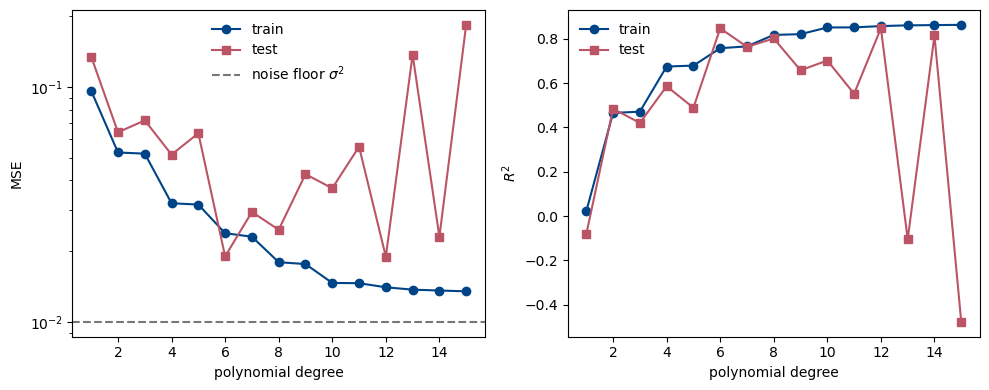

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(degrees, train_mse, 'o-', color=BLUE, label='train')
ax[0].plot(degrees, test_mse, 's-', color=RED, label='test')
ax[0].axhline(0.1 ** 2, ls='--', color=GREY, label=r'noise floor $\sigma^2$')
ax[0].set_yscale('log')
ax[0].set_xlabel('polynomial degree')
ax[0].set_ylabel('MSE')
ax[0].legend(frameon=False)
ax[1].plot(degrees, train_r2, 'o-', color=BLUE, label='train')
ax[1].plot(degrees, test_r2, 's-', color=RED, label='test')
ax[1].set_xlabel('polynomial degree')
ax[1].set_ylabel(r'$R^2$')
ax[1].legend(frameon=False)
fig.tight_layout()
savefig('a_mse_r2', fig)
plt.show()

### Coefficients versus degree

The norm of the fitted coefficients grows with the degree. Large, oscillating coefficients are the signature of the high variance that drives the rise in the test error, and they are what Ridge and Lasso later penalise.

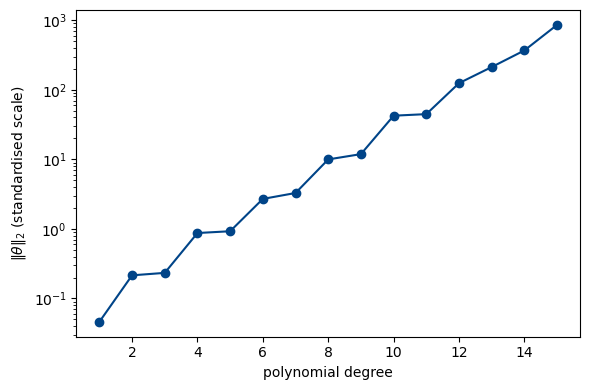

In [5]:
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(degrees, theta_norm, 'o-', color=BLUE)
ax2.set_yscale('log')
ax2.set_xlabel('polynomial degree')
ax2.set_ylabel(r'$\|\theta\|_2$ (standardised scale)')
fig2.tight_layout()
savefig('a_theta_norm', fig2)
plt.show()

### Scaling and conditioning

We standardise each feature on the training mean and standard deviation, centre the target and use no intercept column. For OLS the fitted predictions are invariant to a per-feature rescaling in exact arithmetic, so scaling does not change the MSE. What it changes is the conditioning of $X^T X$, which controls the numerical stability of the solve and, in parts b and e, the convergence of gradient descent. The figure shows that the condition number still reaches about $10^{10}$ at degree 15 even after standardisation: scaling removes the difference in column magnitudes but not the strong correlation between the polynomial columns, which is the real source of the ill-conditioning. Scaling on the training statistics only, never the test set, avoids leaking test information into the fit.

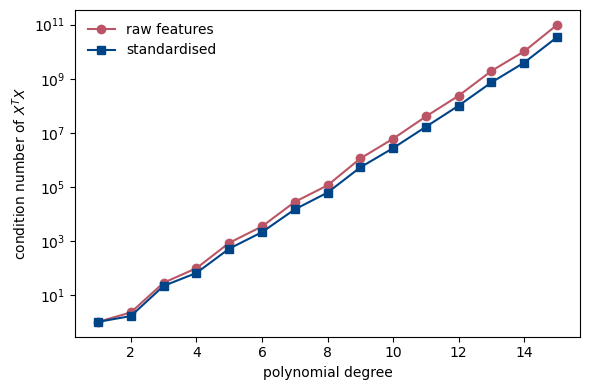

In [6]:
fig3, ax3 = plt.subplots(figsize=(6, 4))
ax3.plot(degrees, cond_raw, 'o-', color=RED, label='raw features')
ax3.plot(degrees, cond_scaled, 's-', color=BLUE, label='standardised')
ax3.set_yscale('log')
ax3.set_xlabel('polynomial degree')
ax3.set_ylabel(r'condition number of $X^T X$')
ax3.legend(frameon=False)
fig3.tight_layout()
savefig('a_conditioning', fig3)
plt.show()

### Dependence on the number of data points

Repeating the degree sweep for $n = 50, 100, 400$ shows that more data pushes the onset of overfitting to higher degree and lowers the test error, since the variance term falls as the sample grows.

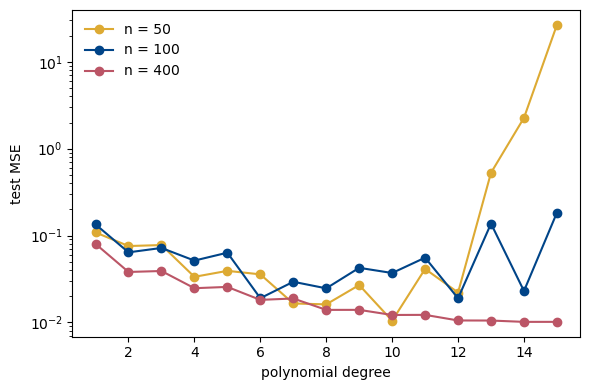

In [7]:
fig4, ax4 = plt.subplots(figsize=(6, 4))
for nn, col in zip((50, 100, 400), (YELLOW, BLUE, RED)):
    xn, yn = make_data(n=nn, noise=0.1, seed=SEED)
    tmse = []
    for d in degrees:
        X = polynomial_features(xn, d)
        Xtr, Xte, ytr, yte = split(X, yn, test_size=0.2, seed=SEED)
        Xtr_s, Xte_s, ytr_c, yte_c, _ = scale_center(Xtr, Xte, ytr, yte)
        th = ols_svd(Xtr_s, ytr_c)
        tmse.append(mse(yte_c, Xte_s @ th))
    ax4.plot(degrees, tmse, 'o-', color=col, label=f'n = {nn}')
ax4.set_yscale('log')
ax4.set_xlabel('polynomial degree')
ax4.set_ylabel('test MSE')
ax4.legend(frameon=False)
fig4.tight_layout()
savefig('a_ndata', fig4)
plt.show()

### Dependence on the noise level

We repeat the degree sweep at three noise levels, $\sigma = 0.05, 0.1, 0.2$, to check that the conclusions do not depend on the particular noise we chose. More noise raises the floor of the test error and pulls the useful degree slightly lower, but the U shape and the bias variance reading stay the same.

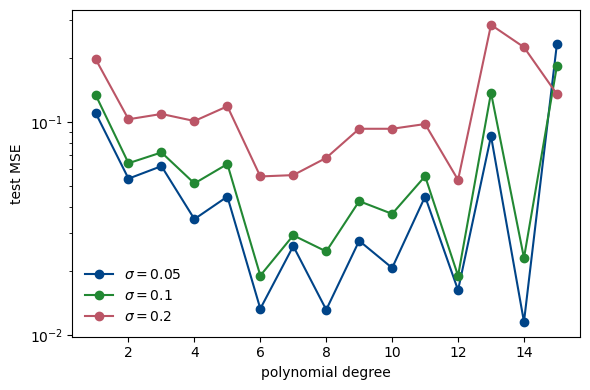

In [8]:
# Dependence on the noise level sigma
from common import BLUE, GREEN, RED

fig_sig, ax_sig = plt.subplots(figsize=(6, 4))
for sig, col in zip([0.05, 0.1, 0.2], [BLUE, GREEN, RED]):
    xs, ys = make_data(n=n, noise=sig, seed=SEED)
    test_mse_sig = []
    for d in degrees:
        Xd = polynomial_features(xs, d)
        Xtr, Xte, ytr, yte = split(Xd, ys, test_size=0.2, seed=SEED)
        Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
        th = ols_svd(Xtr, ytr)
        test_mse_sig.append(mse(yte, Xte @ th))
    ax_sig.plot(degrees, test_mse_sig, 'o-', color=col, label=f'$\\sigma={sig}$')
ax_sig.set_yscale('log')
ax_sig.set_xlabel('polynomial degree')
ax_sig.set_ylabel('test MSE')
ax_sig.legend(frameon=False)
fig_sig.tight_layout()
savefig('a_noise', fig_sig)
plt.show()

## Part b: Ridge

Ridge adds the penalty $\lambda\|\theta\|^2$ to the OLS cost. We use our own closed form with the $1/n$ convention, so the penalty enters as $n\lambda I$ and the matching scikit-learn `alpha` is $n\lambda$. We run the same Runge data as part a and study how $\lambda$ changes the fit.

### Test MSE versus degree for several lambda

A small penalty lets us go to higher degree without the test error blowing up. A large penalty makes the model too stiff and raises the error again.

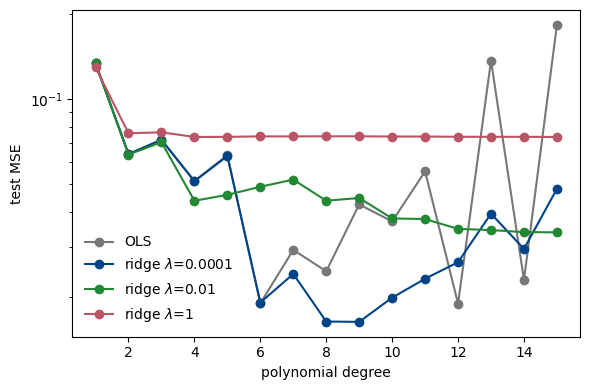

In [9]:
degrees = list(range(1, 16))
lambdas = [0.0, 1e-4, 1e-2, 1.0]
colors = [GREY, BLUE, GREEN, RED]

fig, ax = plt.subplots(figsize=(6, 4))
for lam, col in zip(lambdas, colors):
    row = []
    for d in degrees:
        X = polynomial_features(x, d)
        Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
        Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
        th = ridge_closed_form(Xtr, ytr, lam) if lam > 0 else ols_svd(Xtr, ytr)
        row.append(mse(yte, Xte @ th))
    label = 'OLS' if lam == 0 else f'ridge $\\lambda$={lam:g}'
    ax.plot(degrees, row, 'o-', color=col, label=label)
ax.set_yscale('log')
ax.set_xlabel('polynomial degree')
ax.set_ylabel('test MSE')
ax.legend(frameon=False)
fig.tight_layout()
savefig('b_mse_degree_lambda', fig)
plt.show()

### Test MSE versus lambda at a fixed degree

At degree 12 we sweep $\lambda$ on a logarithmic grid. A small $\lambda$ gives the lowest test error, below the plain OLS value, because it damps the unstable high-degree directions. Too large a $\lambda$ underfits.

best lambda 1.06e-05, test MSE 0.01433; OLS 0.01894


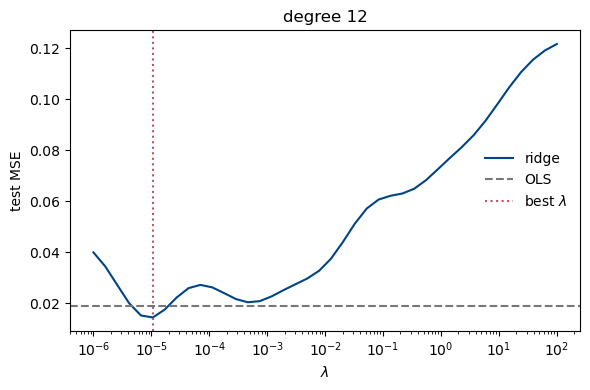

In [10]:
d = 12
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)

lams = np.logspace(-6, 2, 40)
mses = [mse(yte, Xte @ ridge_closed_form(Xtr, ytr, l)) for l in lams]
ols_mse = mse(yte, Xte @ ols_svd(Xtr, ytr))
best = int(np.argmin(mses))
print(f'best lambda {lams[best]:.2e}, test MSE {mses[best]:.5f}; OLS {ols_mse:.5f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lams, mses, '-', color=BLUE, label='ridge')
ax.axhline(ols_mse, ls='--', color=GREY, label='OLS')
ax.axvline(lams[best], ls=':', color=RED, label='best $\\lambda$')
ax.set_xscale('log')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('test MSE')
ax.set_title(f'degree {d}')
ax.legend(frameon=False)
fig.tight_layout()
savefig('b_mse_vs_lambda', fig)
plt.show()

### Singular-value shrinkage

Section 3.8 explains what Ridge does in the SVD basis. Write $X = U S V^T$ with singular values $s_i$. The OLS coefficient in mode $i$ is $(U^T y)_i / s_i$, while Ridge multiplies it by the filter factor $f_i = s_i^2 / (s_i^2 + n\lambda)$. Modes with a large singular value are left almost untouched, and modes with a small singular value, which are the noisy and ill-conditioned directions, are shrunk toward zero. The figure shows the filter factors against the singular value for three values of $\lambda$.

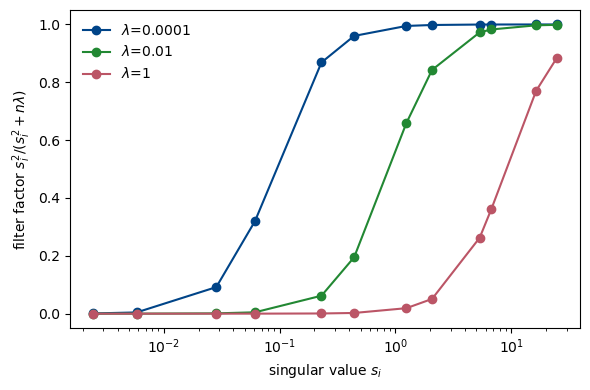

In [11]:
n_train = Xtr.shape[0]
U, s, Vt = np.linalg.svd(Xtr, full_matrices=False)

fig, ax = plt.subplots(figsize=(6, 4))
for lam, col in zip([1e-4, 1e-2, 1.0], [BLUE, GREEN, RED]):
    f = s ** 2 / (s ** 2 + n_train * lam)
    ax.plot(s, f, 'o-', color=col, label=f'$\\lambda$={lam:g}')
ax.set_xscale('log')
ax.set_xlabel('singular value $s_i$')
ax.set_ylabel(r'filter factor $s_i^2/(s_i^2+n\lambda)$')
ax.legend(frameon=False)
fig.tight_layout()
savefig('b_shrinkage', fig)
plt.show()

### Summary of part b

Ridge does not change the model, it changes which directions the fit trusts. A small $\lambda$ shrinks only the smallest singular-value modes and gives a lower test error than OLS at high degree. This is the same instability that the growing OLS coefficients showed in part a, now controlled by the penalty. Parts c and d select $\lambda$ properly with resampling instead of a single test split.